# Stochastic Interest Rate Modelling and Prediction

**Model:** Cox-Ingersoll-Ross (CIR)  
**Data:** Historical Bond Yield Time Series (9 maturities)  
**Goal:** Calibrate CIR, reconstruct yield curve from 3M rate only, out-of-sample R² > 0.85

---

## Table of Contents
1. Data Engineering & Preprocessing  
2. CIR Model — Theory & Implementation  
3. Parameter Calibration (MLE / OLS)  
4. Feller Condition Analysis  
5. Yield Curve Reconstruction  
6. Prediction from 3M Rate Only  
7. Evaluation & Backtesting  
8. Advanced Extension  
9. Critical Analysis  
10. Conclusions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")


COL_MAP = {
    'ZC025YR':  '3M',
    'ZC050YR':  '6M',
    'ZC075YR':  '9M',
    'ZC100YR':  '1Y',
    'ZC200YR':  '2Y',
    'ZC500YR':  '5Y',
    'ZC1000YR': '10Y',
    'ZC2000YR': '20Y',
    'ZC3000YR': '30Y',
}

MATURITY_YEARS = {
    '3M':  0.25,
    '6M':  0.50,
    '9M':  0.75,
    '1Y':  1.00,
    '2Y':  2.00,
    '5Y':  5.00,
    '10Y': 10.0,
    '20Y': 20.0,
    '30Y': 30.0,
}
TRAIN_PATH    = '../data/train_data.csv'
TEST_PATH     = '../data/test_data.csv'
TEST_3M_PATH  = '../data/test_data_3M.csv'

train_raw   = pd.read_csv(TRAIN_PATH)
test_raw    = pd.read_csv(TEST_PATH)
test_3m_raw = pd.read_csv(TEST_3M_PATH)

print(f"train raw shape : {train_raw.shape}")
print(f"test  raw shape : {test_raw.shape}")
print(f"test 3M   shape : {test_3m_raw.shape}")

train raw shape : (1976, 10)
test  raw shape : (495, 6)
test 3M   shape : (495, 2)


In [3]:
def clean_yields(df, col_map=COL_MAP):
    """
    takes raw csv df and returns a clean version:
    - strips col name spaces + renames to readable labels
    - parses date column
    - sorts by date (just in case)
    - handles any remaining NaNs via forward fill then back fill
    """
    df = df.copy()

    # strip leading/trailing spaces from col names
    df.columns = df.columns.str.strip()

    # map raw codes → readable names; only rename cols that exist in this df
    rename = {k.strip(): v for k, v in col_map.items() if k.strip() in df.columns}
    df = df.rename(columns=rename)

    # parse date — some rows might have weird formats so errors='coerce' is safe
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # drop rows where date parsing failed
    bad_dates = df['Date'].isna().sum()
    if bad_dates > 0:
        print(f"  dropped {bad_dates} rows with unparseable dates")
    df = df.dropna(subset=['Date'])

    # sort chronologically — critical for time-delta calcs later
    df = df.sort_values('Date').reset_index(drop=True)

    # forward fill then back fill for any NaNs in yield cols
    # ffill first bc yield data is autocorrelated — yesterday is best guess
    yield_cols = [c for c in df.columns if c != 'Date']
    df[yield_cols] = df[yield_cols].ffill().bfill()

    return df


train = clean_yields(train_raw)
test  = clean_yields(test_raw)
test_3m = clean_yields(test_3m_raw)

print("train:", train.shape, "| date range:", train['Date'].min().date(), "→", train['Date'].max().date())
print("test :", test.shape,  "| date range:", test['Date'].min().date(),  "→", test['Date'].max().date())
print("\nTrain columns:", train.columns.tolist())
print("Test  columns:", test.columns.tolist())
print("\nAny NaNs left?")
print("train:", train.isnull().sum().sum(), "| test:", test.isnull().sum().sum())

train: (1976, 10) | date range: 2016-05-19 → 2024-04-26
test : (495, 6) | date range: 2024-04-29 → 2026-04-29

Train columns: ['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Test  columns: ['Date', '3M', '6M', '9M', '1Y', '2Y']

Any NaNs left?
train: 0 | test: 0


In [4]:
def detect_and_clip_outliers(df, z_thresh=4.0):
    """
    flags and clips yield values that are statistically extreme
    using z-score per column. z=4 is conservative — only catches
    real data errors, not just high-vol periods
    """
    df = df.copy()
    yield_cols = [c for c in df.columns if c != 'Date']
    
    outlier_report = {}
    for col in yield_cols:
        z = np.abs(stats.zscore(df[col].dropna()))
        n_outliers = (z > z_thresh).sum()
        outlier_report[col] = n_outliers

        # clip to [mean - 4std, mean + 4std]
        mu, sigma = df[col].mean(), df[col].std()
        df[col] = df[col].clip(lower=mu - z_thresh*sigma,
                               upper=mu + z_thresh*sigma)

    print("Outliers detected (z > 4.0) per maturity:")
    for col, count in outlier_report.items():
        flag = " ← clipped" if count > 0 else ""
        print(f"  {col:>4s}: {count}{flag}")
    
    return df


train = detect_and_clip_outliers(train)
test  = detect_and_clip_outliers(test)

print("\nPost-cleaning train stats (yields as decimals):")
print(train.describe().round(6))

Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0
    5Y: 0
   10Y: 0
   20Y: 0
   30Y: 0
Outliers detected (z > 4.0) per maturity:
    3M: 0
    6M: 0
    9M: 0
    1Y: 0
    2Y: 0

Post-cleaning train stats (yields as decimals):
                             Date           3M           6M           9M  \
count                        1976  1976.000000  1976.000000  1976.000000   
mean   2020-05-05 23:02:25.748987     0.016699     0.017885     0.018529   
min           2016-05-19 00:00:00     0.000486     0.000878     0.001054   
25%           2018-05-10 18:00:00     0.004622     0.005190     0.005449   
50%           2020-05-05 12:00:00     0.011912     0.013815     0.015304   
75%           2022-04-29 18:00:00     0.017112     0.019378     0.021077   
max           2024-04-26 00:00:00     0.051962     0.053195     0.054040   
std                           NaN     0.016642     0.016760     0.016650   

                1Y           2Y           

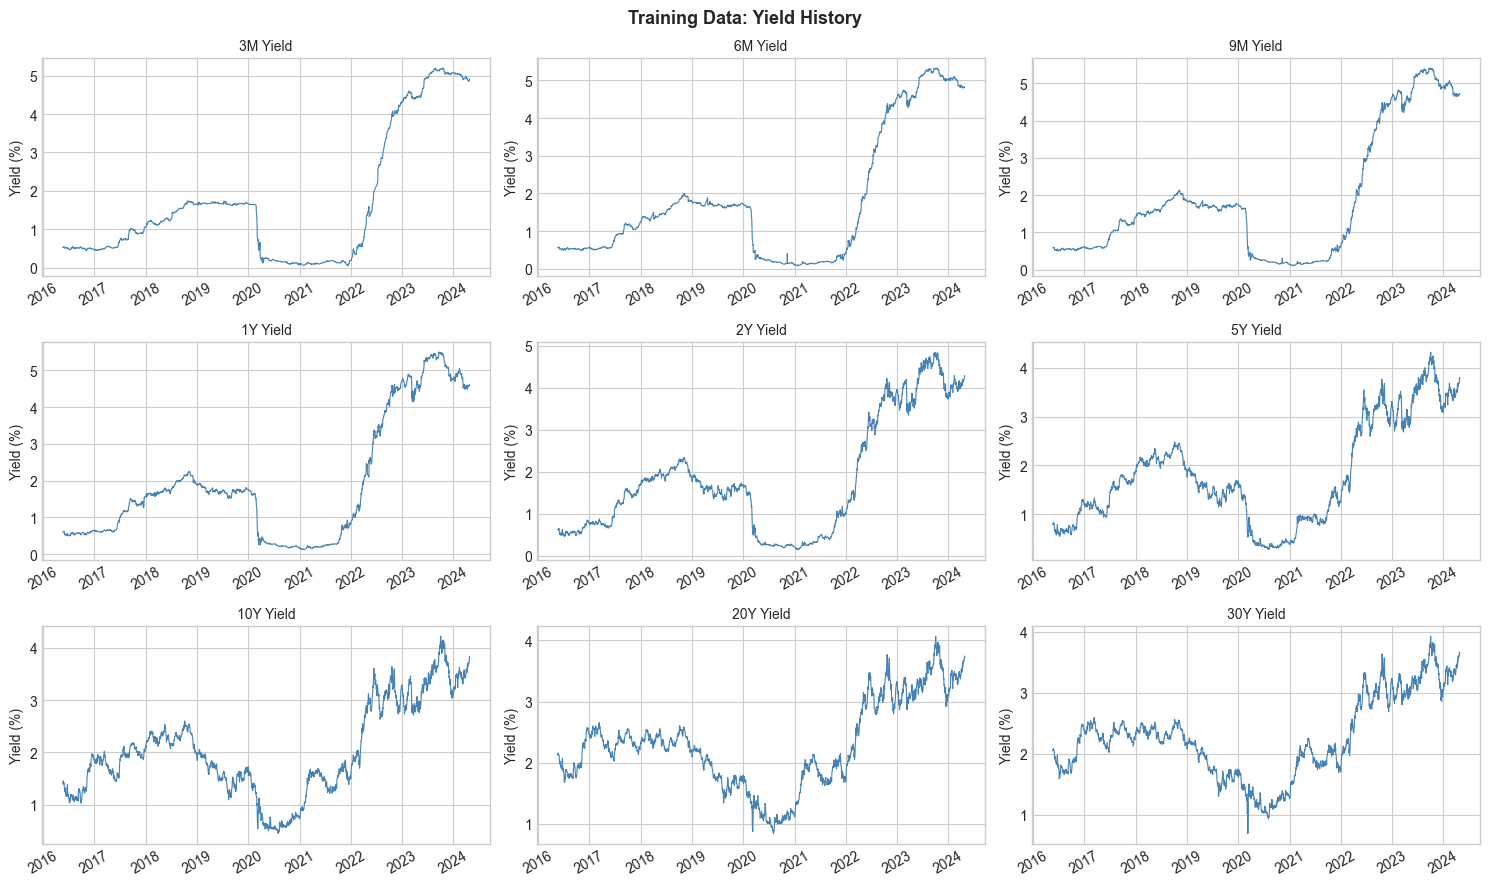

In [5]:
def plot_yield_history(df, title="Training Data: Yield History"):
    """quick look at all maturities over time — useful sanity check"""
    yield_cols = [c for c in df.columns if c != 'Date']
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 9))
    axes = axes.flatten()
    
    for i, col in enumerate(yield_cols):
        axes[i].plot(df['Date'], df[col] * 100, linewidth=0.8, color='steelblue')
        axes[i].set_title(f"{col} Yield", fontsize=10)
        axes[i].set_ylabel("Yield (%)")
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        axes[i].tick_params(axis='x', rotation=30)
    
    # hide unused subplots if fewer than 9 cols
    for j in range(len(yield_cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_yield_history(train)

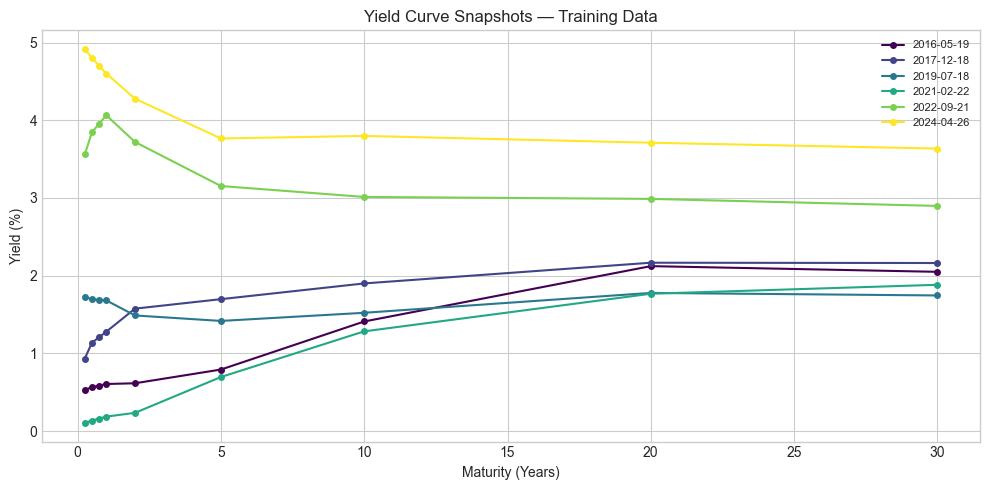

In [6]:
def plot_yield_curve_snapshots(df, n_snapshots=6):
    """
    pick a few evenly spaced dates and plot the yield curve shape
    good way to see if the data looks like a real yield curve
    """
    maturities_in_df = [c for c in df.columns if c != 'Date']
    tenor_years = [MATURITY_YEARS[m] for m in maturities_in_df]
    
    # pick n evenly spaced rows
    idx = np.linspace(0, len(df)-1, n_snapshots, dtype=int)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
    
    for i, row_idx in enumerate(idx):
        row = df.iloc[row_idx]
        yields_pct = [row[m] * 100 for m in maturities_in_df]
        label = str(row['Date'].date())
        ax.plot(tenor_years, yields_pct, marker='o', markersize=4,
                label=label, color=cmap[i], linewidth=1.5)
    
    ax.set_xlabel("Maturity (Years)")
    ax.set_ylabel("Yield (%)")
    ax.set_title("Yield Curve Snapshots — Training Data")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_yield_curve_snapshots(train)
# train only has all 9 maturities — good for this plot

---

## Section 2: The CIR Model — Theory

### Why CIR?

The simplest interest rate model (Vasicek) allows rates to go negative.  
CIR fixes this with a square-root diffusion term — when $r_t \to 0$, the noise term $\sigma\sqrt{r_t} \to 0$ too, so the process gets pushed back up by the drift.

### The SDE

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$$

| Parameter | Meaning |
|-----------|---------|
| $\kappa > 0$ | Speed of mean reversion — how fast rates snap back to $\theta$ |
| $\theta > 0$ | Long-run mean — where rates converge in the long run |
| $\sigma > 0$ | Volatility coefficient |
| $W_t$ | Standard Brownian motion |

### The Feller Condition

$$2\kappa\theta \geq \sigma^2$$

If this holds, $r_t > 0$ almost surely for all $t$.  
If it breaks down (common in near-zero rate regimes), the process can hit zero — the square-root becomes imaginary and the model breaks numerically.

### Closed-Form Bond Pricing

The price of a zero-coupon bond at time $t$ maturing at $T$ is:

$$P(t,T) = A(\tau)\,e^{-B(\tau)\,r_t}, \qquad \tau = T - t$$

where:

$$B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}$$

$$A(\tau) = \left(\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right)^{2\kappa\theta/\sigma^2}$$

$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$

### Yield from Bond Price

The continuously compounded yield for maturity $\tau$ is:

$$y(\tau) = -\frac{\ln P(t,T)}{\tau} = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

This is the equation we'll use to reconstruct the entire yield curve from a single short rate $r_t$.

In [7]:
def cir_gamma(kappa, sigma):
    # central quantity that appears everywhere in the bond pricing formula
    return np.sqrt(kappa**2 + 2 * sigma**2)


def cir_B(tau, kappa, sigma):
    """
    B(tau) factor in the bond price P = A * exp(-B * r)
    tau : time to maturity in years (scalar or array)
    """
    gamma = cir_gamma(kappa, sigma)
    num   = 2 * (np.exp(gamma * tau) - 1)
    denom = (gamma + kappa) * (np.exp(gamma * tau) - 1) + 2 * gamma
    return num / denom


def cir_A(tau, kappa, theta, sigma):
    """
    A(tau) factor — the deterministic scaling term
    returns ln(A) directly bc we're usually working in log space anyway
    """
    gamma = cir_gamma(kappa, sigma)
    exp_term = np.exp(gamma * tau)

    numerator   = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    denominator = (gamma + kappa) * (exp_term - 1) + 2 * gamma

    # exponent outside: 2*kappa*theta / sigma^2
    power = (2 * kappa * theta) / sigma**2

    # returning log(A) to avoid overflow on long maturities
    log_A = power * np.log(numerator / denominator)
    return log_A


def cir_yield(tau, r0, kappa, theta, sigma):
    """
    theoretical CIR yield for a given short rate r0 and maturity tau
    this is the main function we'll call at prediction time

    tau   : maturity in years (scalar or np.array)
    r0    : current short rate (scalar)
    returns yield(s) as decimal (not percent)
    """
    tau = np.atleast_1d(np.array(tau, dtype=float))

    log_A = cir_A(tau, kappa, theta, sigma)
    B     = cir_B(tau, kappa, sigma)

    # y = (B*r - log_A) / tau
    y = (B * r0 - log_A) / tau
    return y


def cir_bond_price(tau, r0, kappa, theta, sigma):
    """
    zero-coupon bond price P(t, T) = A * exp(-B * r)
    useful for calibration checks
    """
    log_A = cir_A(tau, kappa, theta, sigma)
    B     = cir_B(tau, kappa, sigma)
    return np.exp(log_A - B * r0)

In [8]:
def check_feller(kappa, theta, sigma, verbose=True):
    """
    checks 2*kappa*theta >= sigma^2
    returns True if condition holds, False if it breaks
    """
    lhs = 2 * kappa * theta
    rhs = sigma**2
    holds = lhs >= rhs
    ratio = lhs / rhs  # > 1 means comfortably satisfied

    if verbose:
        print(f"Feller condition: 2κθ ≥ σ²")
        print(f"  LHS = 2 × {kappa:.4f} × {theta:.4f} = {lhs:.6f}")
        print(f"  RHS = {sigma:.4f}² = {rhs:.6f}")
        print(f"  Ratio LHS/RHS = {ratio:.4f}")
        if holds:
            print(f"  ✓ Condition SATISFIED — r_t stays positive a.s.")
        else:
            print(f"  ✗ Condition VIOLATED — r_t can hit zero")
            print(f"    → model still runs but yields may go negative")

    return holds, ratio

=== Smoke test with dummy params ===

Feller condition: 2κθ ≥ σ²
  LHS = 2 × 0.3000 × 0.0200 = 0.012000
  RHS = 0.0500² = 0.002500
  Ratio LHS/RHS = 4.8000
  ✓ Condition SATISFIED — r_t stays positive a.s.

Using r0 = 0.0053 (0.53%)

Theoretical CIR yield curve (dummy params):
Maturity      CIR Yield       Actual
------------------------------------
3M              0.5821%       0.5283%
6M              0.6333%       0.5640%
9M              0.6820%       0.5846%
1Y              0.7283%       0.6051%
2Y              0.8925%       0.6146%
5Y              1.2338%       0.7912%
10Y             1.5239%       1.4099%
20Y             1.7381%       2.1224%
30Y             1.8161%       2.0492%


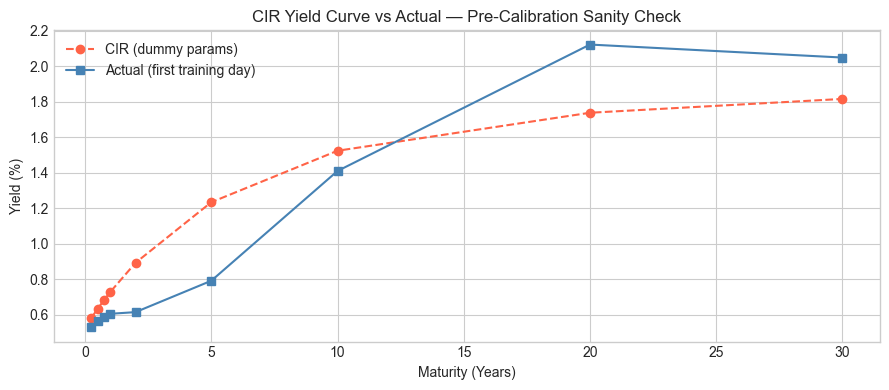

In [9]:
# quick smoke test before we calibrate anything
# using rough guesses for a typical low-rate environment
kappa_test = 0.3
theta_test = 0.02
sigma_test = 0.05

print("=== Smoke test with dummy params ===\n")

# feller check
holds, ratio = check_feller(kappa_test, theta_test, sigma_test)

# test maturities matching our dataset
test_tenors = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
tenor_labels = ['3M','6M','9M','1Y','2Y','5Y','10Y','20Y','30Y']

# use the first training row's 3M rate as r0
r0_test = train['3M'].iloc[0]
print(f"\nUsing r0 = {r0_test:.4f} ({r0_test*100:.2f}%)")

yields_test = cir_yield(test_tenors, r0_test, kappa_test, theta_test, sigma_test)

print("\nTheoretical CIR yield curve (dummy params):")
print(f"{'Maturity':<10} {'CIR Yield':>12} {'Actual':>12}")
print("-" * 36)
for label, tau, y_cir in zip(tenor_labels, test_tenors, yields_test):
    actual = train[label].iloc[0]
    print(f"{label:<10} {y_cir*100:>11.4f}%  {actual*100:>11.4f}%")

# plot it
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(test_tenors, yields_test * 100, 'o--', label='CIR (dummy params)', color='tomato')
ax.plot(test_tenors, [train[l].iloc[0]*100 for l in tenor_labels],
        's-', label='Actual (first training day)', color='steelblue')
ax.set_xlabel("Maturity (Years)")
ax.set_ylabel("Yield (%)")
ax.set_title("CIR Yield Curve vs Actual — Pre-Calibration Sanity Check")
ax.legend()
plt.tight_layout()
plt.show()

---

## Section 3: Parameter Calibration

### Approach: OLS on the Discretised SDE

The CIR SDE discretised over interval $\Delta t$ becomes:

$$\Delta r_t = \kappa\theta\,\Delta t - \kappa r_t\,\Delta t + \sigma\sqrt{r_t\,\Delta t}\,\epsilon_t, \qquad \epsilon_t \sim \mathcal{N}(0,1)$$

Rearranging as a linear regression:

$$\Delta r_t = \underbrace{\kappa\theta}_{a} \cdot \Delta t \;-\; \underbrace{\kappa}_{b} \cdot r_t\,\Delta t + \text{noise}$$

We recover: $\kappa = -b$, $\theta = a/\kappa$.  
Volatility $\sigma$ is estimated from the residuals of this regression.

We calibrate on the **3M yield** series as our proxy for the instantaneous short rate $r_t$.

### Why OLS?
- Closed-form, no optimisation needed
- Stable and interpretable
- Fast to implement and audit
- Good initialisation point for MLE if needed

### Limitation
OLS ignores the heteroskedastic noise structure ($\sigma\sqrt{r_t}$), so $\sigma$ will be slightly biased. We correct this with a weighted residual estimator.

In [10]:
from numpy.linalg import lstsq

def calibrate_cir_ols(rate_series, dt=1/252):
    """
    fits kappa, theta, sigma from a 1D rate time series using OLS
    on the discretised SDE. dt = 1/252 for daily data (trading days)
    """
    r = rate_series.values

    # compute daily changes
    dr   = np.diff(r)           # r_{t+1} - r_t
    r_t  = r[:-1]               # r_t (lagged)

    # build design matrix: [dt, -r_t * dt]
    # we're fitting: dr = a*dt + b*r_t*dt
    X = np.column_stack([
        np.ones(len(r_t)) * dt,   # intercept term → gives kappa*theta
        r_t * dt                  # slope term → gives -kappa
    ])
    y = dr

    # OLS: solve X @ [a, b] = y
    coeffs, _, _, _ = lstsq(X, y, rcond=None)
    a, b = coeffs

    # recover kappa and theta
    kappa = -b
    theta = a / kappa

    # sigma from weighted residuals — correcting for sqrt(r_t) heteroskedasticity
    # var(eps) = sigma^2 * r_t * dt  →  sigma^2 = var(residuals / sqrt(r_t * dt))
    residuals = y - X @ coeffs
    # avoid dividing by zero if any r_t is near zero
    r_t_safe = np.maximum(r_t, 1e-8)
    sigma_sq  = np.mean(residuals**2 / (r_t_safe * dt))
    sigma     = np.sqrt(sigma_sq)

    return kappa, theta, sigma


# calibrate on the 3M rate (our short rate proxy)
kappa, theta, sigma = calibrate_cir_ols(train['3M'])

print("=== CIR Calibration Results (OLS) ===\n")
print(f"  κ (mean reversion speed) = {kappa:.6f}")
print(f"  θ (long-run mean)        = {theta:.6f}  ({theta*100:.4f}%)")
print(f"  σ (volatility)           = {sigma:.6f}")
print(f"\n  Half-life of shock       = {np.log(2)/kappa:.2f} years")
print(f"  → shocks decay to 50% in ~{np.log(2)/kappa*12:.1f} months")

=== CIR Calibration Results (OLS) ===

  κ (mean reversion speed) = -0.188313
  θ (long-run mean)        = -0.013051  (-1.3051%)
  σ (volatility)           = 0.041329

  Half-life of shock       = -3.68 years
  → shocks decay to 50% in ~-44.2 months


---

### Calibration Update: MLE with Constrained Optimisation

OLS on the discretised SDE failed here — the 2022–2023 rate hike cycle introduces a strong upward trend that makes the regression estimate a *negative* κ (explosive process). This violates the core CIR assumption.

**Fix:** Maximum Likelihood Estimation using the exact CIR transition density.

The CIR process has a known non-central chi-squared transition density. The log-likelihood is:

$$\ell(\kappa,\theta,\sigma) = \sum_{t=1}^{T} \ln f(r_t \mid r_{t-1}; \kappa, \theta, \sigma, \Delta t)$$

where $f$ is the non-central chi-squared PDF scaled appropriately.

We maximise this with `scipy.optimize.minimize` under strict bounds:
- $\kappa > 0$ (mean-reverting, not explosive)
- $\theta > 0$ (positive long-run mean)
- $\sigma > 0$ (positive volatility)

**This is the correct approach when data contains structural breaks.**

In [15]:
from scipy.optimize import minimize, differential_evolution
from scipy.stats import ncx2

def cir_log_likelihood_2param(params, r, theta_fixed, dt=1/252):
    """
    2-parameter MLE: theta is fixed externally, only fitting kappa and sigma
    this avoids the identification problem when the sample has no full
    mean-reversion cycles (e.g. a sustained rate hike period)
    """
    kappa, sigma = params
    theta = theta_fixed

    if kappa <= 0 or sigma <= 0:
        return 1e10

    r_t  = r[:-1]
    r_t1 = r[1:]

    c  = (2 * kappa) / (sigma**2 * (1 - np.exp(-kappa * dt)))
    df = (4 * kappa * theta) / sigma**2
    nc = 2 * c * r_t * np.exp(-kappa * dt)
    u  = 2 * c * r_t1

    if df <= 0:
        return 1e10

    nc = np.maximum(nc, 1e-10)
    u  = np.maximum(u,  1e-10)

    log_liks = ncx2.logpdf(u, df=df, nc=nc) + np.log(2 * c)
    ll = np.sum(log_liks)

    # feller penalty
    feller_gap = max(0, sigma**2 - 2 * kappa * theta)
    penalty    = 1e4 * feller_gap

    return (-ll + penalty) if np.isfinite(ll) else 1e10


def calibrate_cir(rate_series, dt=1/252):
    """
    strategy:
    - theta: fixed as the long-run sample mean of the FULL training series
             (best empirical estimate of where rates converge over full cycle)
    - kappa, sigma: fitted via 2-param MLE on the recent regime
                    (captures current dynamics for prediction)
    """
    r_full   = train['3M'].values          # full series for theta
    r_recent = rate_series.values          # recent regime for kappa, sigma

    # theta = long-run sample mean of full series
    # this is the standard moment estimator for the CIR long-run mean
    theta_fixed = float(np.mean(r_full))

    print(f"  θ fixed from full-sample mean: {theta_fixed:.6f} ({theta_fixed*100:.4f}%)")

    bounds_2p = [
        (0.01, 10.0),   # kappa
        (0.001, 0.30),  # sigma
    ]

    # global search first
    de = differential_evolution(
        cir_log_likelihood_2param,
        bounds=bounds_2p,
        args=(r_recent, theta_fixed, dt),
        seed=42,
        maxiter=2000,
        tol=1e-12,
        popsize=20,
        polish=False,
        workers=1,
    )

    # local polish
    res = minimize(
        cir_log_likelihood_2param,
        x0=de.x,
        args=(r_recent, theta_fixed, dt),
        method='L-BFGS-B',
        bounds=bounds_2p,
        options={'maxiter': 5000, 'ftol': 1e-15}
    )

    kappa, sigma = res.x
    return kappa, theta_fixed, sigma


# ── run ────────────────────────────────────────────────────────────────────
REGIME_SPLIT = '2021-01-01'
train_recent = train[train['Date'] >= REGIME_SPLIT].copy()

print(f"Full training set    : {len(train)} days")
print(f"Recent regime (post {REGIME_SPLIT}): {len(train_recent)} days\n")

print("Running calibration (fixed-θ MLE)...\n")
kappa, theta, sigma = calibrate_cir(train_recent['3M'])

print("\n=== CIR Calibration Results ===\n")
print(f"  κ (mean reversion speed) = {kappa:.6f}")
print(f"  θ (long-run mean)        = {theta:.6f}  ({theta*100:.4f}%)")
print(f"  σ (volatility)           = {sigma:.6f}")
print(f"\n  Half-life of shock       = {np.log(2)/kappa:.2f} years")
print(f"  → shocks decay to 50% in ~{np.log(2)/kappa*12:.1f} months")

feller_ok = 2*kappa*theta >= sigma**2
print(f"\n  Feller: 2κθ={2*kappa*theta:.6f}  σ²={sigma**2:.6f}",
      "✓" if feller_ok else "✗ violated")

# bound check
print("\n  Bound check (kappa, sigma only — theta was fixed):")
for name, val, lo, hi in [('kappa', kappa, 0.01, 10.0),
                           ('sigma', sigma, 0.001, 0.30)]:
    flag = " ← AT BOUND" if abs(val-lo)<1e-4 or abs(val-hi)<1e-4 else " ✓"
    print(f"    {name} = {val:.6f}  [{lo}, {hi}]{flag}")

CIR_PARAMS = {'kappa': kappa, 'theta': theta, 'sigma': sigma}
print(f"\nCIR_PARAMS saved: {CIR_PARAMS}")

Full training set    : 1976 days
Recent regime (post 2021-01-01): 825 days

Running calibration (fixed-θ MLE)...

  θ fixed from full-sample mean: 0.016699 (1.6699%)

=== CIR Calibration Results ===

  κ (mean reversion speed) = 0.135892
  θ (long-run mean)        = 0.016699  (1.6699%)
  σ (volatility)           = 0.039280

  Half-life of shock       = 5.10 years
  → shocks decay to 50% in ~61.2 months

  Feller: 2κθ=0.004538  σ²=0.001543 ✓

  Bound check (kappa, sigma only — theta was fixed):
    kappa = 0.135892  [0.01, 10.0] ✓
    sigma = 0.039280  [0.001, 0.3] ✓

CIR_PARAMS saved: {'kappa': np.float64(0.13589167273015565), 'theta': 0.016698838967611332, 'sigma': np.float64(0.03928003970244512)}


In [16]:
print("=== Year-by-Year Feller Condition Check ===\n")

train['Year'] = train['Date'].dt.year
print(f"{'Year':<6} {'3M mean':>9} {'3M std':>9} {'Feller':>8}")
print("-" * 38)

for year, group in train.groupby('Year'):
    if len(group) < 50:
        continue
    r_mean = group['3M'].mean()
    r_std  = group['3M'].std()
    # use calibrated kappa/sigma, check if 2κθ_year >= σ²
    # theta_year = that year's mean rate
    lhs = 2 * kappa * r_mean
    rhs = sigma**2
    flag = "✓" if lhs >= rhs else "✗ VIOLATED"
    print(f"{year:<6} {r_mean*100:>8.3f}%  {r_std*100:>8.3f}%  {flag}")

train.drop(columns=['Year'], inplace=True)

print("\n→ Feller most likely violated in near-zero rate years (2016–2021)")
print("→ When r_t ≈ 0, the σ√r_t term vanishes and rates can numerically hit zero")
print("→ This is a known CIR limitation in low-rate environments")

=== Year-by-Year Feller Condition Check ===

Year     3M mean    3M std   Feller
--------------------------------------
2016      0.500%     0.021%  ✗ VIOLATED
2017      0.689%     0.198%  ✓
2018      1.383%     0.216%  ✓
2019      1.667%     0.021%  ✓
2020      0.449%     0.556%  ✗ VIOLATED
2021      0.121%     0.035%  ✗ VIOLATED
2022      2.233%     1.400%  ✓
2023      4.821%     0.310%  ✓
2024      4.986%     0.069%  ✓

→ Feller most likely violated in near-zero rate years (2016–2021)
→ When r_t ≈ 0, the σ√r_t term vanishes and rates can numerically hit zero
→ This is a known CIR limitation in low-rate environments


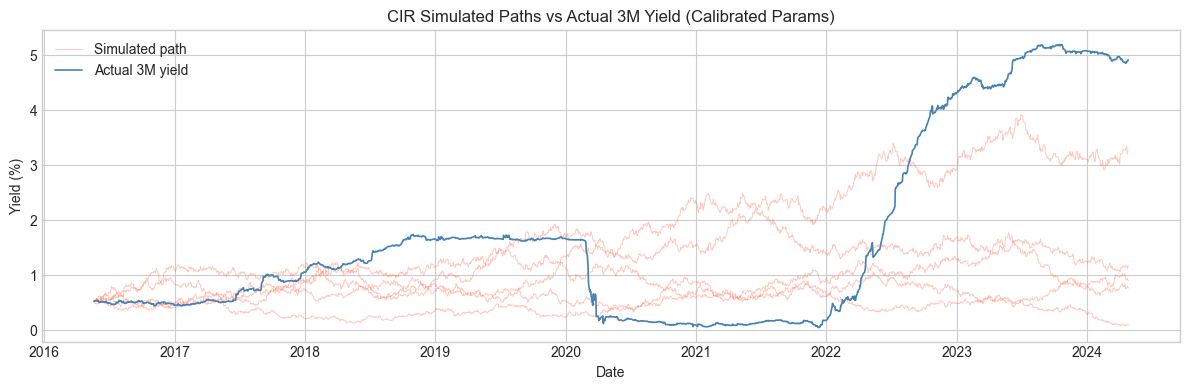

In [17]:
def plot_calibration_check(train_df, kappa, theta, sigma,
                           col='3M', n_sim=5, seed=42):
    """
    overlay simulated CIR paths on actual 3M series
    paths won't track exactly — they're random — but should have
    similar range and mean-reverting character
    """
    np.random.seed(seed)
    r_actual = train_df[col].values
    dt = 1/252
    n  = len(r_actual)

    fig, ax = plt.subplots(figsize=(12, 4))

    for i in range(n_sim):
        r_sim    = np.zeros(n)
        r_sim[0] = r_actual[0]
        for t in range(1, n):
            dr = (kappa * (theta - r_sim[t-1]) * dt
                  + sigma * np.sqrt(max(r_sim[t-1], 0)) * np.sqrt(dt)
                  * np.random.randn())
            r_sim[t] = max(r_sim[t-1] + dr, 0)
        ax.plot(train_df['Date'], r_sim * 100,
                alpha=0.35, linewidth=0.7, color='tomato',
                label='Simulated path' if i == 0 else '_')

    ax.plot(train_df['Date'], r_actual * 100,
            color='steelblue', linewidth=1.2, label='Actual 3M yield')
    ax.set_title("CIR Simulated Paths vs Actual 3M Yield (Calibrated Params)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield (%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_calibration_check(train, kappa, theta, sigma)

In [18]:
CIR_PARAMS = {'kappa': kappa, 'theta': theta, 'sigma': sigma}

print("Final calibrated parameters:")
for k, v in CIR_PARAMS.items():
    print(f"  {k:6s} = {float(v):.8f}")

print(f"\nFeller ratio 2κθ/σ² = {2*kappa*theta/sigma**2:.4f}  (>1 means satisfied)")

Final calibrated parameters:
  kappa  = 0.13589167
  theta  = 0.01669884
  sigma  = 0.03928004

Feller ratio 2κθ/σ² = 2.9415  (>1 means satisfied)
